In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')

# The axis labels below use the book's molar underbar, \underline{V}. With no LaTeX
# installed, matplotlib renders math with its own mathtext engine, which only learned
# \underline in 3.11 -- and Colab still ships 3.10. This upgrades it there, and does
# nothing at all on a machine that already has 3.11 or newer.
#
# ON COLAB THIS NEEDS A SESSION RESTART. Colab imports matplotlib as the session
# starts, so pip can replace the files on disk but not the module already loaded in
# memory: without a restart the kernel keeps running 3.10 and the labels still fail.
# One click, once per session. The cell prints the instruction when it applies.
from importlib.metadata import version

if tuple(map(int, version("matplotlib").split(".")[:2])) < (3, 11):
    !pip install -q "matplotlib>=3.11"
    if "matplotlib" in sys.modules:
        print("\n" + "=" * 72)
        print("  matplotlib was upgraded so this notebook can draw the book's notation.")
        print("  RESTART NOW:   Runtime > Restart session,   then Run all.")
        print("  Colab only, once per session. Without it the next figure will fail.")
        print("=" * 72 + "\n")
# ---------------------------------------------------------------------------



# Will these two liquids mix? (isobutane / furfural)

This notebook works **Illustration 11.2-2**: the compositions of the two coexisting
liquid phases in an isobutane + furfural mixture at 37.8 °C and 5 bar, predicted from
the van Laar model with the constants Table 9.5-1 already gives.

**Why anyone cares.** Furfural is an industrial extraction solvent — it is used to pull
aromatics out of lubricating oil and butadiene out of a C₄ stream — and it works
*because* it will not dissolve paraffins. A solvent that mixes with everything extracts
nothing. So the engineering question behind this illustration is not "does it split?"
but "how far apart are the two phases?", and that is the number a separation is designed
around.

**What is new here relative to Chapter 10.** The equilibrium condition is the same one
as always, equal fugacity of each species in every phase. What changes is that both
phases are now liquids described by the *same* activity coefficient model, so the
$\gamma$'s no longer cancel against a reference state — they are the entire physics. A
mixture splits when its activity coefficients get large enough that the same species is
happier in two different environments than in one.

**This is also the illustration whose printed solution says to use MATHCAD**, and
that is exactly what the notebook replaces.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026


In [2]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt

from thermo.activity_models import VanLaar
from thermo.charts import use_book_style
from thermo import lle

use_book_style()

T = 273.15 + 37.8                       # K
model = VanLaar(alpha=2.62, beta=3.02)  # SIS Table 9.5-1, isobutane (1) / furfural (2)

print(f"T = {T:.2f} K = 37.8 C")
print(f"van Laar  alpha = {model.alpha}   beta = {model.beta}")
print(f"infinite-dilution activity coefficients: "
      f"gamma_1(x1->0) = {np.exp(model.alpha):.1f}, "
      f"gamma_2(x2->0) = {np.exp(model.beta):.1f}")

T = 310.95 K = 37.8 C
van Laar  alpha = 2.62   beta = 3.02
infinite-dilution activity coefficients: gamma_1(x1->0) = 13.7, gamma_2(x2->0) = 20.5



Those two numbers settle it in advance. An activity coefficient of 14 at
infinite dilution means a molecule of isobutane surrounded by furfural has an escaping
tendency fourteen times what an ideal solution would give it — it is being squeezed out.
Once $\gamma$ gets that large the mixture can lower its Gibbs energy by giving up the
entropy of mixing and splitting in two.

## The equilibrium condition

Equal fugacity for each species in the two liquid phases, with the same standard state
on both sides, reduces to SIS Eq. 11.2-2:

$$x_i^{\rm I}\,\gamma_i(x^{\rm I}, T) \;=\; x_i^{\rm II}\,\gamma_i(x^{\rm II}, T)
  \qquad i = 1, 2$$

Two equations, two unknowns ($x_1^{\rm I}$ and $x_1^{\rm II}$; the other mole fractions
follow by summing to one). Pressure has almost dropped out — liquids are nearly
incompressible, so the 5 bar in the problem statement is there to keep both phases
liquid, not because the answer depends on it.

**And there is a trap in that equation that no amount of care with the solver will
fix.** $x^{\rm I} = x^{\rm II}$ satisfies it identically, at every temperature, for every
model. A Newton solver handed a guess near the middle will converge onto that trivial
root, report success, and hand back a "phase split" in which the two phases are the same
phase. `binary_lle` therefore does not start from a guess at all: it starts from the
**lower convex hull of the Gibbs energy of mixing** — the common-tangent construction
drawn schematically in Fig. 11.2-5 — which cannot produce a trivial seed, and it checks
afterwards that the tangent really does lie below the curve.


In [3]:
xI, xII = lle.binary_lle(model, T)
gI, gII = model.gamma(xI, T), model.gamma(xII, T)

printed = {"x1^I": 0.1128, "x2^I": 0.8872, "x1^II": 0.9284, "x2^II": 0.0716,
           "gamma_1^I": 8.375, "gamma_2^I": 1.030,
           "gamma_1^II": 1.018, "gamma_2^II": 12.77}
got = {"x1^I": xI[0], "x2^I": xI[1], "x1^II": xII[0], "x2^II": xII[1],
       "gamma_1^I": gI[0], "gamma_2^I": gI[1],
       "gamma_1^II": gII[0], "gamma_2^II": gII[1]}

print(f"  {'':11s} {'computed':>10s} {'SIS 11.2-2':>11s}")
for k, p in printed.items():
    print(f"  {k:11s} {got[k]:10.4f} {p:11.4f}")

print(f"\n  phase I  is furfural-rich:  {xI[1]:.1%} furfural")
print(f"  phase II is isobutane-rich: {xII[0]:.1%} isobutane")

                computed  SIS 11.2-2
  x1^I            0.1128      0.1128
  x2^I            0.8872      0.8872
  x1^II           0.9284      0.9284
  x2^II           0.0716      0.0716
  gamma_1^I       8.3751      8.3750
  gamma_2^I       1.0303      1.0300
  gamma_1^II      1.0176      1.0180
  gamma_2^II     12.7717     12.7700

  phase I  is furfural-rich:  88.7% furfural
  phase II is isobutane-rich: 92.8% isobutane



## The check that costs nothing

The solve returns two compositions. The *test* that they are an equilibrium state is
that the two products $x_i\gamma_i$ come out the same in both phases — which is Eq.
11.2-2 read backwards, and the illustration prints both numbers for exactly that reason.
Print them side by side and the equality is visible rather than asserted.


In [4]:
print(f"  {'':8s} {'phase I':>10s} {'phase II':>10s}   SIS")
print(f"  x1 g1   {xI[0] * gI[0]:10.4f} {xII[0] * gII[0]:10.4f}   0.945")
print(f"  x2 g2   {xI[1] * gI[1]:10.4f} {xII[1] * gII[1]:10.4f}   0.914")

              phase I   phase II   SIS
  x1 g1       0.9448     0.9448   0.945
  x2 g2       0.9140     0.9140   0.914



## Where the split comes from: the Gibbs energy of mixing

Eq. 11.2-2 gives the answer without saying why. The reason is in the shape of
$\Delta_{\rm mix}\underline{G}$, drawn here once for a real system rather
than taking Fig. 11.2-5's schematic on faith.

A mixture is stable against splitting only where $\Delta_{\rm mix}\underline{G}$ is
convex. Where the curve bulges *upward*, a mixture of that overall composition can
reach a lower Gibbs energy by separating into two phases whose compositions are joined
by a straight line — the **common tangent** — lying under the curve. The two points
where that tangent touches are the coexisting compositions, and they are the same two
numbers the equation solver just produced. They are not the two minima of the curve, and
they are not the inflection points (those are the *spinodal*, the limit of metastability,
Eq. 11.2-13).


  common tangent touches at x1 = 0.1128 and 0.9284   (the answer above)
  spinodal (open squares)  at x1 = 0.2702 and 0.8052
  between them the mixture is unstable to any fluctuation; between the
  spinodal and the binodal it is metastable and will separate slowly


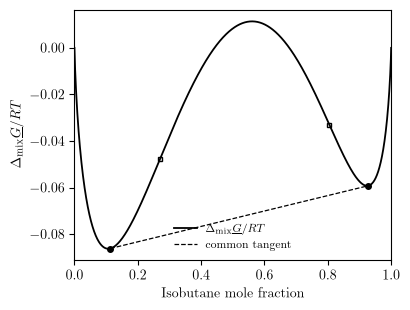

In [5]:
x1 = np.linspace(1e-6, 1 - 1e-6, 1001)
g = lle.gmix_over_RT(model, x1, T)

a, b = xI[0], xII[0]
ga, gb = lle.gmix_over_RT(model, a, T), lle.gmix_over_RT(model, b, T)
tangent = ga + (gb - ga) * (x1 - a) / (b - a)
sp = lle.spinodal(model, T)

fig, ax = plt.subplots(figsize=(4.2, 3.2))
ax.plot(x1, g, "k-", lw=1.3, label=r"$\Delta_{\rm mix}\underline{G}/RT$")
ax.plot(x1[(x1 > a) & (x1 < b)], tangent[(x1 > a) & (x1 < b)], "k--", lw=0.9,
        label="common tangent")
ax.plot([a, b], [ga, gb], "ko", ms=4)
for s in sp:
    ax.plot(s, lle.gmix_over_RT(model, s, T), "ks", ms=3.5, mfc="none")
ax.set_xlabel("Isobutane mole fraction")
ax.set_ylabel(r"$\Delta_{\rm mix}\underline{G}/RT$")
ax.set_xlim(0, 1)
ax.legend(fontsize=8, frameon=False, loc="lower center")
fig.tight_layout()

print(f"  common tangent touches at x1 = {a:.4f} and {b:.4f}   (the answer above)")
print(f"  spinodal (open squares)  at x1 = {sp[0]:.4f} and {sp[1]:.4f}")
print(f"  between them the mixture is unstable to any fluctuation; between the")
print(f"  spinodal and the binodal it is metastable and will separate slowly")


## The same answer from a different algorithm

`binary_lle` is a two-unknown solve seeded from that hull. The method Section 11.2
describes for three components and more is different: guess distribution coefficients
$K_i = x_i^{\rm II}/x_i^{\rm I}$, solve the Rachford-Rice equation for how much of the
feed ends up in each phase, update the $K$'s from the activity coefficients, repeat.
`lle_flash` does that, shares no code with `binary_lle`, and is started here from the
deliberately poor guess $K_1 = 10$, $K_2 = 0.1$ that SIS p. 630 suggests.

Two independent algorithms agreeing to six figures is a real check. One algorithm
agreeing with itself is not.


In [6]:
psi, fI, fII = lle.lle_flash(model, [0.5, 0.5], T, K0=[10.0, 0.1])
lean, rich = (fI, fII) if fI[0] < fII[0] else (fII, fI)

print(f"  binary_lle   x1^I = {xI[0]:.6f}   x1^II = {xII[0]:.6f}")
print(f"  lle_flash    x1^I = {lean[0]:.6f}   x1^II = {rich[0]:.6f}")
print(f"\n  an equimolar feed splits {psi:.3f} / {1 - psi:.3f} between the two phases")

  binary_lle   x1^I = 0.112807   x1^II = 0.928433
  lle_flash    x1^I = 0.112807   x1^II = 0.928433

  an equimolar feed splits 0.475 / 0.525 between the two phases



## Fig. 1 — the graphical construction, and what it is still for

Before equation solvers, this problem was done by hand off a plot of $x_1\gamma_1$ and
$x_2\gamma_2$ against composition. Pick a level for $x_1\gamma_1$; it cuts the curve at
two compositions; check whether $x_2\gamma_2$ is also equal at those two; if not, pick
another level. That is what the illustration's table of fourteen values and its Fig. 1
are for, and it is why the printed solution needs a paragraph of procedure before it can
start.

**The picture survives the method.** Nobody should solve it this way now, but the
figure shows something the numbers do not: the equilibrium is *two horizontal lines
cutting two curves at the same pair of compositions*, and a system that cannot do that —
one whose $x_i\gamma_i$ curves are monotonic — has no phase split at all. The
non-monotonicity is the physics.

**Two entries of the printed table do not reproduce**, and both look like transposed
digits rather than a disagreement about the model. They are flagged below and filed as
an erratum.


In [7]:
# SIS Illustration 11.2-2's table: x1, x1*gamma1, x2*gamma2   (x2 = 1 - x1)
table = [(0.05, 0.5491, 0.9555), (0.10, 0.8843, 0.9231), (0.15, 1.0761, 0.8965),
         (0.20, 1.1734, 0.8805), (0.30, 1.2072, 0.8739), (0.40, 1.1405, 0.9000),
         (0.50, 1.0598, 0.9594), (0.60, 0.9840, 1.0506), (0.70, 0.9322, 1.1607),
         (0.80, 0.9121, 1.2343), (0.85, 0.9161, 1.2071), (0.90, 0.9309, 1.0731),
         (0.95, 0.9582, 0.7325)]

print(f"  {'x1':>5s}  {'x1 g1  SIS':>11s} {'computed':>10s}   "
      f"{'x2 g2  SIS':>11s} {'computed':>10s}")
for x, p1, p2 in table:
    gam = model.gamma([x, 1 - x], T)
    c1, c2 = x * gam[0], (1 - x) * gam[1]
    flag = "  <--" if max(abs(c1 - p1), abs(c2 - p2)) > 1e-3 else ""
    print(f"  {x:5.2f}  {p1:11.4f} {c1:10.4f}   {p2:11.4f} {c2:10.4f}{flag}")

     x1   x1 g1  SIS   computed    x2 g2  SIS   computed
   0.05       0.5491     0.5491        0.9555     0.9555
   0.10       0.8843     0.8842        0.9231     0.9213  <--
   0.15       1.0761     1.0761        0.8965     0.8965
   0.20       1.1734     1.1733        0.8805     0.8805
   0.30       1.2072     1.2072        0.8739     0.8739
   0.40       1.1405     1.1450        0.9000     0.9000  <--
   0.50       1.0598     1.0598        0.9594     0.9594
   0.60       0.9840     0.9840        1.0506     1.0506
   0.70       0.9322     0.9322        1.1607     1.1607
   0.80       0.9121     0.9121        1.2343     1.2343
   0.85       0.9161     0.9161        1.2071     1.2071
   0.90       0.9309     0.9309        1.0731     1.0731
   0.95       0.9582     0.9582        0.7325     0.7325


label collisions: none


wrote pdf/Illustration_11.2-2.pdf


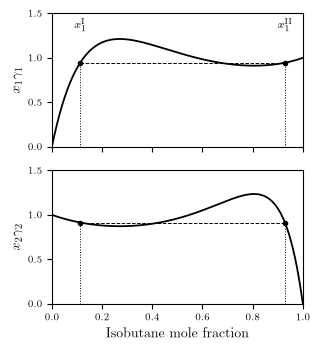

In [8]:
# --- Print art: Illustration 11.2-2, Fig. 1 --------------------------------
#   pdf/Illustration_11.2-2.pdf -> deliverables/figures/print-bw/ch11/c11uf002.pdf
#
# Replaces the inherited c11uf002.eps, which superimposes both curves on one axes. They
# are separated here into two panels, because the construction the surrounding text
# describes is done one curve at a time: a level on x1*gamma1 fixes two compositions,
# and the test is whether the SAME two compositions give one level on x2*gamma2. The
# two levels are 0.945 and 0.914 -- 2 % of the plotted range apart -- so drawn on
# one axes they land on top of each other and the construction is unreadable.
#
# Pure black ink: heavy curves, thin dashed levels, dotted composition lines carried
# through both panels so the eye reads them as one pair.
xs = np.linspace(1e-4, 1 - 1e-4, 801)
gam = np.array([model.gamma([x, 1 - x], T) for x in xs])
y1, y2 = xs * gam[:, 0], (1 - xs) * gam[:, 1]

L1, L2 = xI[0] * gI[0], xI[1] * gI[1]        # the two equal products

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3.3, 3.6), sharex=True)

for ax, y, L, lab in ((ax1, y1, L1, r"$x_1\gamma_1$"),
                      (ax2, y2, L2, r"$x_2\gamma_2$")):
    ax.plot(xs, y, "k-", lw=1.3)
    ax.plot([a, b], [L, L], "k--", lw=0.7)
    ax.plot([a, b], [L, L], "ko", ms=3)
    for xv in (a, b):
        ax.plot([xv, xv], [0, L], "k:", lw=0.7)
    ax.set_ylabel(lab)
    ax.set_ylim(0, 1.5)
    ax.set_yticks(np.arange(0, 1.51, 0.5))
    ax.tick_params(labelsize=7)

ax1.text(a, 1.30, r"$x_1^{\rm I}$", fontsize=8, ha="center", va="bottom")
ax1.text(b, 1.30, r"$x_1^{\rm II}$", fontsize=8, ha="center", va="bottom")

ax2.set_xlabel("Isobutane mole fraction")
ax2.set_xlim(0, 1)
ax2.set_xticks(np.arange(0, 1.01, 0.2))

fig.canvas.draw()
rend = fig.canvas.get_renderer()
boxes = [(t.get_text(), t.get_window_extent(renderer=rend))
         for ax in (ax1, ax2) for t in ax.texts]
clash = [(p, q) for i, (p, bp) in enumerate(boxes) for q, bq in boxes[i + 1:]
         if bp.overlaps(bq)]
print("label collisions:", clash if clash else "none")
assert not clash, "two labels overlap; move one before staging this art"

os.makedirs("pdf", exist_ok=True)
fig.tight_layout()
fig.savefig("pdf/Illustration_11.2-2.pdf", dpi=300, bbox_inches="tight")
print("wrote pdf/Illustration_11.2-2.pdf")

## The one intersection that means nothing

The printed art drew both of those curves on a single set of axes, where they cross near
$x_1 = 0.56$. That crossing is the most conspicuous feature of the plot, and it is the
easiest wrong answer to reach for. **It is not the equilibrium, and it is not a
condition of anything.**

Eq. 11.2-2 is an equality *within* one curve, taken between the two phases — never
between the two curves:

$$x_1\gamma_1 = 0.9448 \quad\text{at both } x_1 = 0.1128 \text{ and } 0.9284
\qquad
x_2\gamma_2 = 0.9140 \quad\text{at the same two compositions}$$

One horizontal line per panel, coupled only by the requirement that the *same* pair of
compositions works for both. Across species the two levels are different numbers, and
nothing requires them to agree: $x_1\gamma_1$ is the activity of isobutane and
$x_2\gamma_2$ is the activity of furfural. Two different species, two different
standard states — setting one species' activity equal to another's has no thermodynamic
content. The crossing composition is worse than merely irrelevant: it lies between the
two spinodal points, so it is a single phase that cannot exist at this temperature at
all.

**Why this is a warning and not a footnote.** The trap only springs because this
system is nearly symmetric. When $\alpha = \beta$ the two levels are equal *exactly*, by
symmetry. Isobutane and furfural have $\alpha = 2.62$ against $\beta = 3.02$, so the two
levels land 0.03 apart — about a millimeter at the size the figure prints — and on one
set of axes they read as a single line. A reader who takes "the two products are equal"
as the rule gets the right answer here for the wrong reason, and gets nothing at all on
a system that is not nearly symmetric. That is why Fig. 1 is drawn as two panels.


In [9]:
# Where the curves cross, and why that is not the answer.
from scipy.optimize import brentq

diff = lambda x: x * model.gamma([x, 1 - x], T)[0] - (1 - x) * model.gamma([x, 1 - x], T)[1]
xc = brentq(diff, 0.3, 0.8)
gc = model.gamma([xc, 1 - xc], T)

print(f"  the two curves cross at x1 = {xc:.4f}, where both products = {xc * gc[0]:.4f}")
print(f"  the spinodal spans x1 = {sp[0]:.4f} to {sp[1]:.4f}")
print(f"  the crossing lies inside it ({sp[0] < xc < sp[1]}): a single phase that")
print(f"  cannot exist at this temperature, let alone an equilibrium state\n")

print("  the equilibrium instead -- one level per curve, two compositions each:")
print(f"    x1 g1 = {xI[0] * gI[0]:.4f}  at x1 = {xI[0]:.4f} and {xII[0]:.4f}")
print(f"    x2 g2 = {xI[1] * gI[1]:.4f}  at the same two compositions")
print(f"    the two levels differ by {abs(xI[0] * gI[0] - xI[1] * gI[1]):.4f}, "
      f"and nothing requires them to agree\n")

# How close the two levels land is set by the asymmetry of the model, not by physics.
print("  vary beta and watch the near-agreement disappear:")
print(f"  {'alpha':>7s} {'beta':>6s} {'x1 g1':>8s} {'x2 g2':>8s} {'gap':>7s}")
for al, be in [(2.62, 2.62), (2.62, 3.02), (2.62, 3.60), (2.62, 4.50)]:
    mm = VanLaar(alpha=al, beta=be)
    pI, _ = lle.binary_lle(mm, T)
    gm = mm.gamma(pI, T)
    p1, p2 = pI[0] * gm[0], pI[1] * gm[1]
    note = ("   <-- equal, by symmetry" if al == be else
            "   <-- isobutane / furfural" if be == 3.02 else "")
    print(f"  {al:7.2f} {be:6.2f} {p1:8.4f} {p2:8.4f} {abs(p1 - p2):7.4f}{note}")


  the two curves cross at x1 = 0.5608, where both products = 1.0114
  the spinodal spans x1 = 0.2702 to 0.8052
  the crossing lies inside it (True): a single phase that
  cannot exist at this temperature, let alone an equilibrium state

  the equilibrium instead -- one level per curve, two compositions each:
    x1 g1 = 0.9448  at x1 = 0.1128 and 0.9284
    x2 g2 = 0.9140  at the same two compositions
    the two levels differ by 0.0307, and nothing requires them to agree

  vary beta and watch the near-agreement disappear:
    alpha   beta    x1 g1    x2 g2     gap
     2.62   2.62   0.9137   0.9137  0.0000   <-- equal, by symmetry
     2.62   3.02   0.9448   0.9140  0.0307   <-- isobutane / furfural
     2.62   3.60   0.9708   0.9151  0.0557
     2.62   4.50   0.9889   0.9171  0.0718



## Is the prediction any good?

There are no measured liquid-liquid data for isobutane + furfural, which is honest of
the illustration to say. What it does instead is the right move when a prediction cannot
be checked directly: compare against **neighbors in the same chemical family**. Furfural
with 2,2-dimethylpentane, with 2-methylpentane and with hexane all split, with one phase
holding 89–90 mol % furfural and the other 6–7 mol %.


In [10]:
print(f"  predicted, furfural-rich phase:   {xI[1]:.3f} mole fraction furfural"
      f"   (measured neighbors 0.89 - 0.90)")
print(f"  predicted, isobutane-rich phase:  {xII[1]:.3f}"
      f"   (measured neighbors 0.06 - 0.07)")

  predicted, furfural-rich phase:   0.887 mole fraction furfural   (measured neighbors 0.89 - 0.90)
  predicted, isobutane-rich phase:  0.072   (measured neighbors 0.06 - 0.07)



**Do not read that as validation.** Two van Laar constants fitted to *vapor*-liquid
data have landed inside the range spanned by three different chemicals, which is
encouraging and is not the same as agreeing with a measurement. Liquid-liquid equilibrium
is the most model-sensitive calculation in the book: the compositions come from where two
activity coefficients are large, which is exactly where a model fitted near $x \to 1$ is
extrapolating. The illustration's own Aspen sidebar makes the point more sharply —
UNIFAC, run on the same system, does not agree with this answer at all.

That sensitivity is the reason Section 11.2 warns against predicting LLE with parameters
regressed from VLE, and the reason the UNIFAC method needs a *different* set of group
interaction parameters for liquid-liquid work than for vapor-liquid work.

## Your turn

1. Change the van Laar constants by 5 % each, one at a time, and re-solve. How far do the
   two compositions move? Compare that with the 5 % — this is the sensitivity the section
   warns about, measured rather than asserted.
2. At what temperature does this mixture stop splitting? The van Laar constants here are
   temperature-independent, so it never does. Make $\alpha$ and $\beta$ fall as $1/T$,
   pass a callable to `consolute_temperature`, and find the upper consolute temperature.
3. Solve the same problem with the one-constant Margules model, choosing $A$ so that it
   reproduces $\gamma_1^\infty$. Where does it put the phases, and why is the answer
   symmetric when the real one is not?
4. Feed 1 mol of an equimolar mixture. Use `lle_flash` and then `tie_line_split` to get
   the moles of each species in each phase, and check them against an overall material
   balance.
5. The three-phase pressure of this system is worked in Illustration 11.3-1: a vapor in
   equilibrium with *either* liquid is in equilibrium with both. Take a bubble point on
   each of the two compositions above with `lle.vlle_binary` and confirm the two
   pressures agree.
6. Plot $x_1\gamma_1$ for a mixture that does *not* split — van Laar with
   $\alpha = \beta = 0.8$, say. What happens to the maximum and minimum, and what does
   that say about how large the activity coefficients have to be before two phases are
   possible?
